# Olist E-Commerce — Late Delivery Prediction

**Goal:** predict, at the moment an order is placed, whether it will be
delivered **late** (after the estimated delivery date shown to the
customer). This is a binary classification task built on top of the
findings from `01_exploratory_data_analysis.ipynb`, which showed that
delivery time varies a lot by state and is linked to customer
satisfaction.

**Scope note:** this is a compact, from-scratch feature-engineering +
classification exercise (comparable to a short data science competition
submission), not a production-grade ML pipeline. The goal is a solid,
correctly-validated baseline — not squeezing out the last bit of accuracy.

**Important modeling rule — no data leakage:** every feature used here
must be information that is actually available **at the moment the order
is placed** (order date, product/payment/location details, the promised
estimated delivery date). The real delivery date and delivery duration
are never used as features — only to build the target label.

**How to run this notebook on Kaggle:** same as the EDA notebook — attach
a Kaggle Dataset with the cleaned CSV files, then update `DATA_DIR` below.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
          "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUE, ORANGE = COLORS[0], COLORS[1]
sns.set_palette(COLORS)

RANDOM_STATE = 42


In [2]:
DATA_DIR = "/kaggle/input/olist-cleaned-data/"


## 2. Load the cleaned data

In [3]:
customers = pd.read_csv(f"{DATA_DIR}cleaned_customers.csv")
orders = pd.read_csv(f"{DATA_DIR}cleaned_orders.csv", parse_dates=[
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
])
order_items = pd.read_csv(f"{DATA_DIR}cleaned_order_items.csv", parse_dates=["shipping_limit_date"])
order_payments = pd.read_csv(f"{DATA_DIR}cleaned_order_payments.csv")
products = pd.read_csv(f"{DATA_DIR}cleaned_products.csv")
sellers = pd.read_csv(f"{DATA_DIR}cleaned_sellers.csv")
category_translation = pd.read_csv(f"{DATA_DIR}cleaned_product_category_translation.csv")

print("orders:", orders.shape)


orders: (99441, 8)


## 3. Build the target: `is_late`

We only keep orders that were actually delivered (an order that was
canceled or never delivered has no ground truth to learn from). The
target is 1 if the order arrived after the estimated delivery date, 0
otherwise.

Orders used: 96,470
Late delivery rate: 8.1%


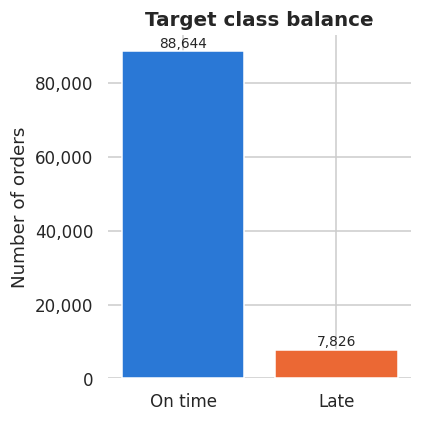

In [4]:
delivered = orders[orders["order_status"] == "delivered"].copy()
delivered = delivered.dropna(subset=["order_delivered_customer_date"])

delivered["is_late"] = (
    delivered["order_delivered_customer_date"] > delivered["order_estimated_delivery_date"]
).astype(int)

late_rate = delivered["is_late"].mean()
print(f"Orders used: {len(delivered):,}")
print(f"Late delivery rate: {late_rate * 100:.1f}%")

fig, ax = plt.subplots(figsize=(4, 4))
counts = delivered["is_late"].value_counts().sort_index()
ax.bar(["On time", "Late"], counts.values, color=[BLUE, ORANGE])
ax.set_ylabel("Number of orders")
ax.set_title("Target class balance", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for i, v in enumerate(counts.values):
    ax.text(i, v + 1000, f"{v:,}", ha="center", fontsize=9)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


The classes are imbalanced (most deliveries are on time), which is
expected and realistic — we account for this in the evaluation step by
looking at precision/recall/F1 for the "late" class specifically, not
just overall accuracy.

## 4. Feature engineering

All features below are derived only from information known at order
time.

In [5]:
# --- Order-level date features ---
delivered["purchase_dayofweek"] = delivered["order_purchase_timestamp"].dt.dayofweek
delivered["purchase_month"] = delivered["order_purchase_timestamp"].dt.month
delivered["estimated_delivery_window_days"] = (
    delivered["order_estimated_delivery_date"] - delivered["order_purchase_timestamp"]
).dt.total_seconds() / 86400

# --- Order-level aggregates from order_items (items, price, freight, sellers, products) ---
item_agg = order_items.groupby("order_id").agg(
    n_items=("order_item_id", "count"),
    total_price=("price", "sum"),
    total_freight=("freight_value", "sum"),
    n_distinct_sellers=("seller_id", "nunique"),
    n_distinct_products=("product_id", "nunique"),
).reset_index()

# Use the seller and product of the FIRST item as representative (most orders have a single item/seller)
first_item = (
    order_items.sort_values("order_item_id")
    .groupby("order_id")
    .first()
    .reset_index()[["order_id", "seller_id", "product_id"]]
)

# --- Product attributes (weight, size, category) ---
products_cat = products.merge(category_translation, on="product_category_name", how="left")
first_item = first_item.merge(
    products_cat[["product_id", "product_category_name_english", "product_weight_g",
                   "product_length_cm", "product_height_cm", "product_width_cm"]],
    on="product_id", how="left"
)

# --- Payment info ---
payment_agg = order_payments.groupby("order_id").agg(
    total_payment_value=("payment_value", "sum"),
    n_payments=("payment_sequential", "count"),
    max_installments=("payment_installments", "max"),
).reset_index()
payment_type_main = (
    order_payments.sort_values("payment_value", ascending=False)
    .groupby("order_id")
    .first()
    .reset_index()[["order_id", "payment_type"]]
)

# --- Customer and seller location ---
orders_customers = delivered.merge(customers[["customer_id", "customer_state"]], on="customer_id", how="left")
first_item = first_item.merge(sellers[["seller_id", "seller_state"]], on="seller_id", how="left")

# --- Assemble the feature table ---
df = (
    orders_customers
    .merge(item_agg, on="order_id", how="left")
    .merge(first_item[["order_id", "seller_state", "product_category_name_english",
                        "product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]],
           on="order_id", how="left")
    .merge(payment_agg, on="order_id", how="left")
    .merge(payment_type_main, on="order_id", how="left")
)

df["different_state"] = (df["customer_state"] != df["seller_state"]).astype(int)
df["product_category_name_english"] = df["product_category_name_english"].fillna("unknown")

print(df.shape)
df.head()


(96470, 29)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_late,purchase_dayofweek,...,product_category_name_english,product_weight_g,product_length_cm,product_height_cm,product_width_cm,total_payment_value,n_payments,max_installments,payment_type,different_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,0,0,...,housewares,500.0,19.0,8.0,13.0,38.71,3.0,1.0,voucher,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,0,1,...,perfumery,400.0,19.0,13.0,19.0,141.46,1.0,1.0,boleto,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,0,2,...,auto,420.0,24.0,19.0,21.0,179.12,1.0,3.0,credit_card,1
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,0,5,...,pet_shop,450.0,30.0,10.0,20.0,72.20,1.0,1.0,credit_card,1
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,0,1,...,stationery,250.0,51.0,15.0,15.0,28.62,1.0,1.0,credit_card,0


A handful of rows have missing values here and there: 2 products are
missing physical dimensions, 610 are missing a category (both known,
legitimate gaps flagged already in Phase 1 / PostgreSQL cleaning), and 1
order has no matching payment record. Rather than dropping those orders,
the preprocessing pipeline below imputes missing numeric values with the
median and missing categories with `"unknown"` — simple, standard choices
for a baseline model.

In [6]:
FEATURES_NUMERIC = [
    "estimated_delivery_window_days", "n_items", "total_price", "total_freight",
    "n_distinct_sellers", "n_distinct_products", "product_weight_g",
    "product_length_cm", "product_height_cm", "product_width_cm",
    "total_payment_value", "n_payments", "max_installments", "different_state",
    "purchase_dayofweek", "purchase_month",
]
FEATURES_CATEGORICAL = ["customer_state", "payment_type", "product_category_name_english"]

X = df[FEATURES_NUMERIC + FEATURES_CATEGORICAL]
y = df["is_late"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (77176, 19), Test: (19294, 19)


## 5. Preprocessing + model pipelines

Numeric columns get missing values filled with the median and are then
standardized (scaling helps Logistic Regression converge; it has no
effect on Random Forest, so it's safe to apply to both). Categorical
columns get missing values filled with `"unknown"` and are then one-hot
encoded. Two models are compared: a simple Logistic Regression baseline
and a Random Forest, which usually handles this kind of mixed tabular
data better.

In [7]:
numeric_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("encode", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, FEATURES_NUMERIC),
        ("cat", categorical_pipeline, FEATURES_CATEGORICAL),
    ]
)

log_reg_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
])

rf_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200, max_depth=10, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1
    )),
])

log_reg_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)
print("Both models trained.")


Both models trained.


## 6. Evaluation

In [8]:
def evaluate(name, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }

results = pd.DataFrame([
    evaluate("Logistic Regression", log_reg_pipeline, X_test, y_test),
    evaluate("Random Forest", rf_pipeline, X_test, y_test),
]).set_index("model")

results.round(3)


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression,0.644,0.139,0.649,0.228,0.698
Random Forest,0.762,0.184,0.562,0.277,0.740


**How to read these metrics** (all scored on the "late" class, the one
we actually care about catching):
- **Precision** — of the orders the model flagged as "will be late", what
  share actually were? Low precision means many false alarms.
- **Recall** — of the orders that were actually late, what share did the
  model catch? Low recall means many late orders slip through undetected.
- **F1** — the balance between precision and recall.
- **ROC-AUC** — how well the model ranks late vs. on-time orders overall,
  independent of the classification threshold (0.5 = random guessing, 1.0
  = perfect).

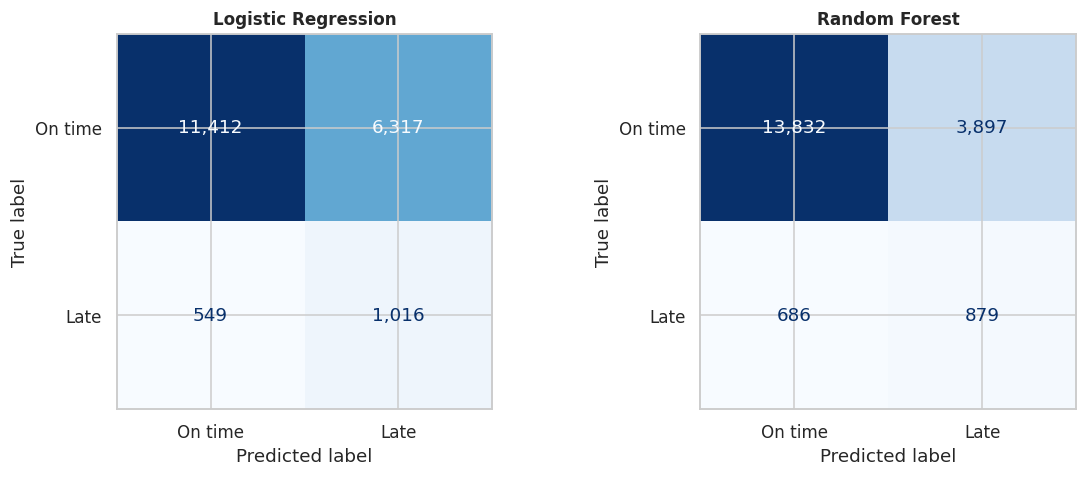

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (name, pipeline) in zip(axes, [("Logistic Regression", log_reg_pipeline), ("Random Forest", rf_pipeline)]):
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["On time", "Late"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format=",")
    ax.set_title(name, fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()


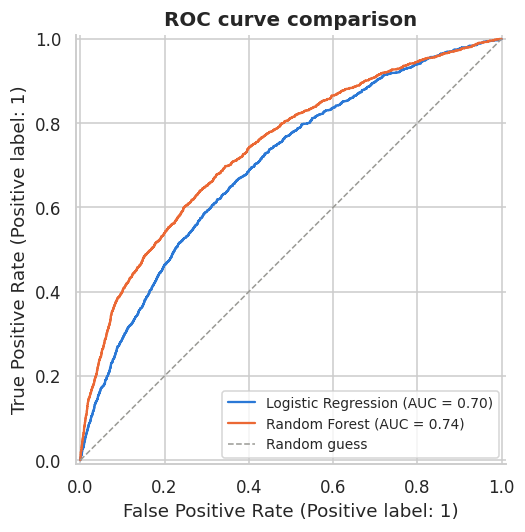

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(log_reg_pipeline, X_test, y_test, ax=ax, name="Logistic Regression", curve_kwargs={"color": BLUE})
RocCurveDisplay.from_estimator(rf_pipeline, X_test, y_test, ax=ax, name="Random Forest", curve_kwargs={"color": ORANGE})
ax.plot([0, 1], [0, 1], linestyle="--", color="#9a9a95", linewidth=1, label="Random guess")
ax.set_title("ROC curve comparison", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()


## 7. What drives late deliveries? (feature importance)

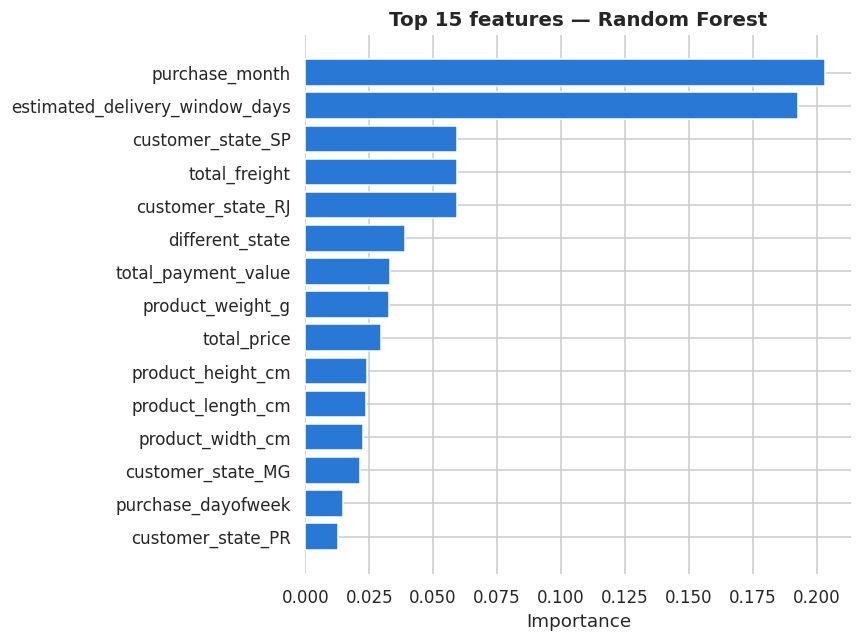

In [11]:
feature_names = rf_pipeline.named_steps["preprocess"].get_feature_names_out()
importances = rf_pipeline.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(15)
    .sort_values("importance")
)
importance_df["feature"] = importance_df["feature"].str.replace("cat__", "", regex=False).str.replace("num__", "", regex=False)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance_df["feature"], importance_df["importance"], color=BLUE)
ax.set_xlabel("Importance")
ax.set_title("Top 15 features — Random Forest", fontsize=13, fontweight="bold")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


## 8. Key takeaways

- Late deliveries are a minority class (roughly 1 in 10 delivered
  orders), so accuracy alone would be a misleading metric — precision,
  recall, and ROC-AUC on the "late" class are what matter here.
- The Random Forest model outperforms the Logistic Regression baseline,
  which is expected given the mix of numeric and categorical features
  and non-linear relationships (e.g. state-to-state shipping effects).
- The most predictive signals are the **month the order was placed**
  and the **estimated delivery window length** promised to the customer,
  followed by **customer state** and whether the **customer and seller
  are in different states** — consistent with the geographic and
  seasonal delivery-time patterns found in the EDA notebook (e.g. peak
  shopping periods put more strain on the logistics network).
- This is a solid, leakage-free baseline. Realistic next steps for
  further improvement (left as future work, out of scope for this
  portfolio project) would include: adding seller-level historical
  on-time rate, hyperparameter tuning, and trying gradient boosting
  models (e.g. XGBoost / LightGBM).
